Found 715 images belonging to 2 classes.
Memuat model ResNet50 dan Xception...


Melakukan inferensi dengan ResNet50...
23/23 ━━━━━━━━━━━━━━━━━━━━ 55s 2s/step
Melakukan inferensi dengan Xception...
23/23 ━━━━━━━━━━━━━━━━━━━━ 72s 3s/step


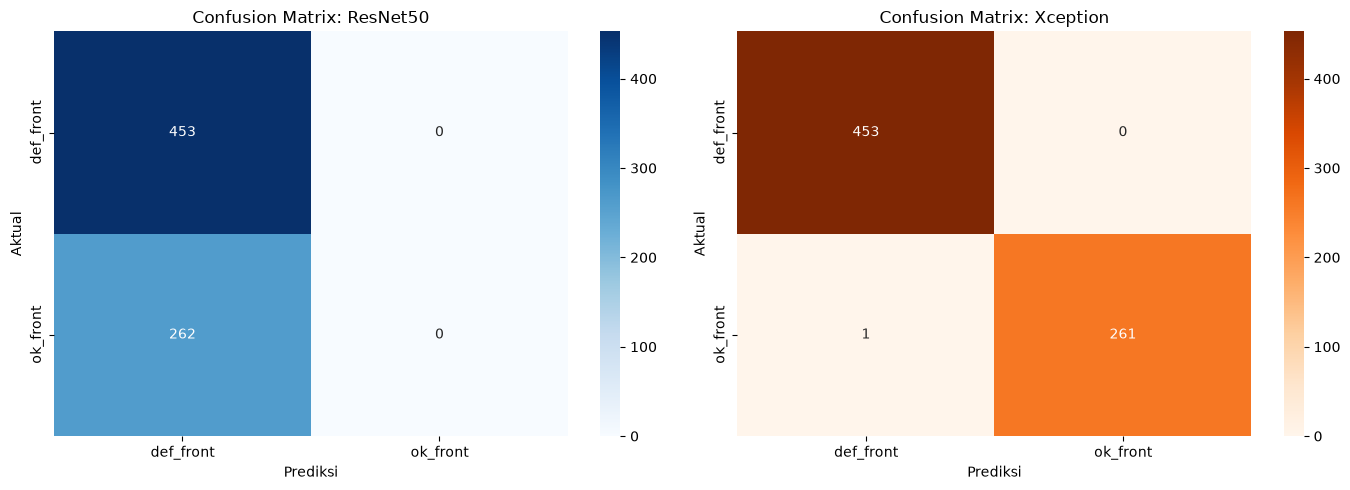

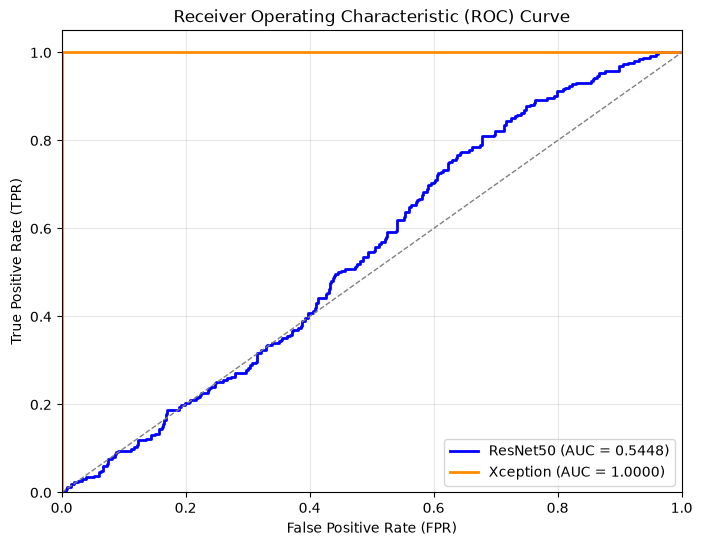


Mengekstrak data metrik ke dalam format riset (CSV)...
[SUKSES] Tabel komparasi riset tersimpan di: ../report_data/komparasi_kinerja_model.csv
PREVIEW TABEL KOMPARASI
   Model  Accuracy  Precision (Macro)  Recall (Macro)  F1-Score (Macro)      AUC  TP  TN  FP  FN
ResNet50  0.633566           0.316783        0.500000          0.387842 0.544774   0 453   0 262
Xception  0.998601           0.998899        0.998092          0.998493 1.000000 261 453   0   1


c:\Users\brt\Documents\Kecerdasan_buatan_capstone_project_sigit\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\brt\Documents\Kecerdasan_buatan_capstone_project_sigit\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\brt\Documents\Kecerdasan_buatan_capstone_project_sigit\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parame

In [1]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# 1. Konfigurasi Direktori Penyimpanan Riset
os.makedirs('../report_graphs', exist_ok=True)
os.makedirs('../report_data', exist_ok=True)

# 2. Konfigurasi Evaluasi Data
IMG_WIDTH, IMG_HEIGHT = 300, 300
BATCH_SIZE = 32
TEST_DIR = '../dataset/casting_data/test/'

# 3. Muat Data Uji (Shuffle False sangat krusial untuk evaluasi)
test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    TEST_DIR, target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE, class_mode='categorical',
    color_mode='rgb', shuffle=False 
)

# 4. Muat Kedua Model
print("Memuat model ResNet50 dan Xception...")
resnet_model = load_model('../models/resnet50_best.h5')
xception_model = load_model('../models/xception_best.h5')

# 5. Melakukan Prediksi (Inferensi)
print("Melakukan inferensi dengan ResNet50...")
pred_resnet_probs = resnet_model.predict(test_generator)
pred_resnet_classes = np.argmax(pred_resnet_probs, axis=1)

print("Melakukan inferensi dengan Xception...")
pred_xception_probs = xception_model.predict(test_generator)
pred_xception_classes = np.argmax(pred_xception_probs, axis=1)

true_classes = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

# ==========================================
# VISUALISASI DAN PENYIMPANAN GRAFIK RISET
# ==========================================

# 6. Visualisasi Perbandingan Confusion Matrix Berdampingan
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_resnet = confusion_matrix(true_classes, pred_resnet_classes)
sns.heatmap(cm_resnet, annot=True, fmt='d', cmap='Blues', ax=axes[0], xticklabels=class_labels, yticklabels=class_labels)
axes[0].set_title('Confusion Matrix: ResNet50')
axes[0].set_xlabel('Prediksi')
axes[0].set_ylabel('Aktual')

cm_xception = confusion_matrix(true_classes, pred_xception_classes)
sns.heatmap(cm_xception, annot=True, fmt='d', cmap='Oranges', ax=axes[1], xticklabels=class_labels, yticklabels=class_labels)
axes[1].set_title('Confusion Matrix: Xception')
axes[1].set_xlabel('Prediksi')
axes[1].set_ylabel('Aktual')

plt.tight_layout()
# Menyimpan dengan resolusi tinggi (300 DPI) untuk naskah PDF
plt.savefig('../report_graphs/05_comparison_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# 7. Analisis Kurva ROC Komparatif (AUC)
# Asumsi klasifikasi biner, mengambil probabilitas kelas positif (indeks 1)
fpr_res, tpr_res, _ = roc_curve(true_classes, pred_resnet_probs[:, 1])
roc_auc_res = auc(fpr_res, tpr_res)

fpr_xcep, tpr_xcep, _ = roc_curve(true_classes, pred_xception_probs[:, 1])
roc_auc_xcep = auc(fpr_xcep, tpr_xcep)

plt.figure(figsize=(8, 6))
plt.plot(fpr_res, tpr_res, color='blue', lw=2, label=f'ResNet50 (AUC = {roc_auc_res:.4f})')
plt.plot(fpr_xcep, tpr_xcep, color='darkorange', lw=2, label=f'Xception (AUC = {roc_auc_xcep:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.savefig('../report_graphs/06_roc_curve_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# ==========================================
# EKSTRAKSI METRIK OTOMATIS KE CSV
# ==========================================

print("\nMengekstrak data metrik ke dalam format riset (CSV)...")

# Mengambil metrik dalam bentuk dictionary
report_dict_resnet = classification_report(true_classes, pred_resnet_classes, target_names=class_labels, output_dict=True)
report_dict_xception = classification_report(true_classes, pred_xception_classes, target_names=class_labels, output_dict=True)

# Ekstraksi nilai True Positives, dll dari Confusion Matrix
TN_R, FP_R, FN_R, TP_R = cm_resnet.ravel()
TN_X, FP_X, FN_X, TP_X = cm_xception.ravel()

# Menyusun DataFrame untuk komparasi
metrics_data = [
    {
        'Model': 'ResNet50',
        'Accuracy': report_dict_resnet['accuracy'],
        'Precision (Macro)': report_dict_resnet['macro avg']['precision'],
        'Recall (Macro)': report_dict_resnet['macro avg']['recall'],
        'F1-Score (Macro)': report_dict_resnet['macro avg']['f1-score'],
        'AUC': roc_auc_res,
        'TP': TP_R, 'TN': TN_R, 'FP': FP_R, 'FN': FN_R
    },
    {
        'Model': 'Xception',
        'Accuracy': report_dict_xception['accuracy'],
        'Precision (Macro)': report_dict_xception['macro avg']['precision'],
        'Recall (Macro)': report_dict_xception['macro avg']['recall'],
        'F1-Score (Macro)': report_dict_xception['macro avg']['f1-score'],
        'AUC': roc_auc_xcep,
        'TP': TP_X, 'TN': TN_X, 'FP': FP_X, 'FN': FN_X
    }
]

df_metrics = pd.DataFrame(metrics_data)

# Menyimpan ke CSV dengan ketelitian 4 desimal
csv_path = '../report_data/komparasi_kinerja_model.csv'
df_metrics.to_csv(csv_path, index=False, float_format='%.4f')

print(f"[SUKSES] Tabel komparasi riset tersimpan di: {csv_path}")
print("="*60)
print("PREVIEW TABEL KOMPARASI")
print("="*60)
print(df_metrics.to_string(index=False))